# Hypothesis Test — Results Display

Read-only companion to `hypothesis_test.ipynb`. This notebook does
**not** train anything; it only reads the cached result JSONs from
`artifacts/hypothesis_test/results/` and produces the six figures plus
the verdict.

Run `hypothesis_test.ipynb` first (or run the parts that have already
finished). Re-running this notebook is cheap and idempotent.


## Setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Paths must match those used by hypothesis_test.ipynb's monkey-patched config.
HT_ROOT    = Path("artifacts/hypothesis_test")
HT_RESULTS = HT_ROOT / "results"
HT_FIGURES = HT_ROOT / "figures"
HT_FIGURES.mkdir(parents=True, exist_ok=True)

# The two MixStyle regimes under test — must match hypothesis_test.ipynb.
STRONG_MS = (0.75, 0.1)
WEAK_MS   = (0.5,  0.5)

assert HT_RESULTS.exists(), (
    f"{HT_RESULTS} does not exist — run hypothesis_test.ipynb first"
)
n_files = len(list(HT_RESULTS.glob("HT-*.json")))
print(f"results dir: {HT_RESULTS}")
print(f"figures dir: {HT_FIGURES}")
print(f"cached HT-*.json files: {n_files}")
if n_files == 0:
    raise RuntimeError(
        "No HT-*.json result files found. Run hypothesis_test.ipynb to "
        "produce them, then come back here."
    )


results dir: artifacts\hypothesis_test\results
figures dir: artifacts\hypothesis_test\figures
cached HT-*.json files: 55


## Aggregate all cached results into a single DataFrame

In [2]:
def _classify(name: str, cfg_dict: dict):
    """Identify regularizer family.

    The saved JSON does NOT record ``use_mixstyle``, and ``mixstyle_p``
    always carries the dataclass default (0.5) — so we can't tell
    Baseline apart from plain MixStyle from the fields alone. Use the
    ``HT-<family>-...`` name prefix as the source of truth, with a
    field-based fallback for safety.
    """
    n = name
    if n.startswith("HT-Baseline"):  return "Baseline"
    if n.startswith("HT-MixStyle"):  return "MixStyle"
    if n.startswith("HT-KLMMD"):     return "KL+MMD"
    if n.startswith("HT-KL-"):       return "KL"
    if n.startswith("HT-Multi-"):    return "Multiscale"
    if n.startswith("HT-MMD-"):      return "MMD"

    # Field-based fallback (covers any non-prefixed name).
    cl  = cfg_dict.get("consistency_lambda") or 0
    ml  = cfg_dict.get("mmd_lambda") or 0
    msw = cfg_dict.get("multiscale_layer_weights") or []
    if cl > 0 and ml > 0: return "KL+MMD"
    if msw:               return "Multiscale"
    if cl > 0:            return "KL"
    if ml > 0:            return "MMD"
    return "MixStyle"

rows = []
for path in sorted(HT_RESULTS.glob("HT-*.json")):
    r = json.loads(path.read_text(encoding="utf-8"))
    fam = _classify(r["name"], r)
    # Baseline rows have no meaningful (p, a) — null them so MixStyle
    # filters at the dataclass-default values cannot accidentally pick
    # them up.
    is_baseline = fam == "Baseline"
    p = None if is_baseline else r.get("mixstyle_p")
    a = None if is_baseline else r.get("mixstyle_a")
    rows.append({
        "name": r["name"],
        "family": fam,
        "p": p,
        "a": a,
        "kl_lambda":  r.get("consistency_lambda") or 0,
        "mmd_lambda": r.get("mmd_lambda") or 0,
        "ms_w": (dict(r.get("multiscale_layer_weights") or {}).get("layer2") or 0),
        "in_acc":  r["in_domain_test_acc"],
        "out_acc": r["out_domain_test_acc"],
        "best_val": r["best_val"],
    })
df = pd.DataFrame(rows)
df["ms_label"] = df.apply(
    lambda r: f"p={r['p']}, a={r['a']}" if pd.notna(r["p"]) else "baseline", axis=1
)
df.sort_values(["family", "ms_label", "kl_lambda", "mmd_lambda", "ms_w"], inplace=True)
display(df.head(30))
print("total rows:", len(df))
print("families found:", sorted(df["family"].unique().tolist()))


,name,family,p,a,kl_lambda,mmd_lambda,ms_w,in_acc,out_acc,best_val,ms_label
0,HT-Baseline-L2,Baseline,NaN,NaN,0.00,0.000,0.0,0.919091,0.892134,0.917581,baseline
1,HT-KL-p0.5-a0.5-lam0.05,KL,0.50,0.5,0.05,0.000,0.0,0.923475,0.884162,0.911195,"p=0.5, a=0.5"
2,HT-KL-p0.5-a0.5-lam0.1,KL,0.50,0.5,0.10,0.000,0.0,0.921084,0.884096,0.912991,"p=0.5, a=0.5"
3,HT-KL-p0.5-a0.5-lam0.5,KL,0.50,0.5,0.50,0.000,0.0,0.921283,0.891539,0.910597,"p=0.5, a=0.5"
4,HT-KL-p0.5-a0.5-lam1.0,KL,0.50,0.5,1.00,0.000,0.0,0.922878,0.896434,0.911195,"p=0.5, a=0.5"
5,HT-KL-p0.5-a0.5-lam2.0,KL,0.50,0.5,2.00,0.000,0.0,0.917298,0.883898,0.909599,"p=0.5, a=0.5"
6,HT-KL-p0.5-a0.5-lam3.0,KL,0.50,0.5,3.00,0.000,0.0,0.917696,0.883071,0.909998,"p=0.5, a=0.5"
7,HT-KL-p0.5-a0.5-lam5.0,KL,0.50,0.5,5.00,0.000,0.0,0.921682,0.901859,0.907803,"p=0.5, a=0.5"
8,HT-KL-p0.75-a0.1-lam0.05,KL,0.75,0.1,0.05,0.000,0.0,0.921483,0.896997,0.913590,"p=0.75, a=0.1"
9,HT-KL-p0.75-a0.1-lam0.1,KL,0.75,0.1,0.10,0.000,0.0,0.923675,0.900370,0.913590,"p=0.75, a=0.1"


total rows: 55
families found: ['Baseline', 'KL', 'KL+MMD', 'MMD', 'MixStyle', 'Multiscale']


## Plot 1 — KL λ-sweep overlay

Two lines, one per MixStyle config. Reference dashed lines for
baseline and plain MixStyle (per MS regime).

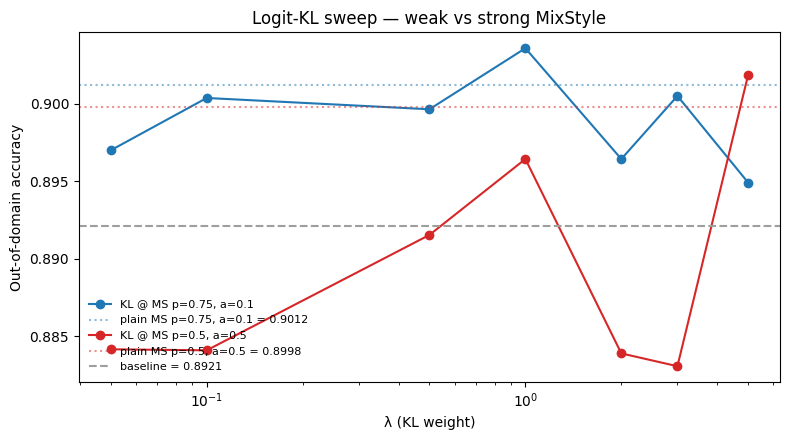

In [3]:
plain_ms_out = {
    f"p={p}, a={a}": df[(df["family"]=="MixStyle") & (df["p"]==p) & (df["a"]==a)]["out_acc"].iloc[0]
    for (p, a) in (STRONG_MS, WEAK_MS)
}
baseline_out = df[df["family"]=="Baseline"]["out_acc"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4.5))
for (p, a), color in zip([STRONG_MS, WEAK_MS], ["#1f77b4", "#d62728"]):
    sub = df[(df["family"]=="KL") & (df["p"]==p) & (df["a"]==a)].sort_values("kl_lambda")
    ax.plot(sub["kl_lambda"], sub["out_acc"], marker="o", color=color,
            label=f"KL @ MS p={p}, a={a}")
    ax.axhline(plain_ms_out[f"p={p}, a={a}"], color=color, linestyle=":", alpha=0.5,
               label=f"plain MS p={p}, a={a} = {plain_ms_out[f'p={p}, a={a}']:.4f}")
ax.axhline(baseline_out, color="#9e9e9e", linestyle="--", label=f"baseline = {baseline_out:.4f}")
ax.set_xscale("log")
ax.set_xlabel("λ (KL weight)")
ax.set_ylabel("Out-of-domain accuracy")
ax.set_title("Logit-KL sweep — weak vs strong MixStyle")
ax.legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout()
plt.savefig(HT_FIGURES / "fig1_kl_sweep.png", bbox_inches="tight")
plt.show()


## Plot 2 — Multiscale weight overlay

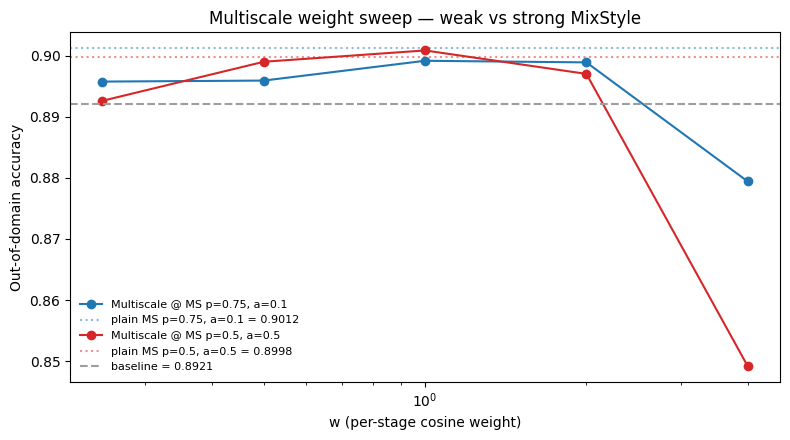

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
any_data = False
for (p, a), color in zip([STRONG_MS, WEAK_MS], ["#1f77b4", "#d62728"]):
    sub = df[(df["family"]=="Multiscale") & (df["p"]==p) & (df["a"]==a)].sort_values("ms_w")
    if not sub.empty:
        ax.plot(sub["ms_w"], sub["out_acc"], marker="o", color=color,
                label=f"Multiscale @ MS p={p}, a={a}")
        any_data = True
    ax.axhline(plain_ms_out[f"p={p}, a={a}"], color=color, linestyle=":", alpha=0.5,
               label=f"plain MS p={p}, a={a} = {plain_ms_out[f'p={p}, a={a}']:.4f}")
ax.axhline(baseline_out, color="#9e9e9e", linestyle="--", label=f"baseline = {baseline_out:.4f}")
if any_data:
    ax.set_xscale("log")
else:
    ax.text(0.5, 0.5, "no Multiscale runs yet", ha="center", va="center",
            transform=ax.transAxes, fontsize=11, color="#666")
ax.set_xlabel("w (per-stage cosine weight)")
ax.set_ylabel("Out-of-domain accuracy")
ax.set_title("Multiscale weight sweep — weak vs strong MixStyle")
ax.legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout()
plt.savefig(HT_FIGURES / "fig2_multiscale_sweep.png", bbox_inches="tight")
plt.show()


## Plot 3 — MMD-λ overlay

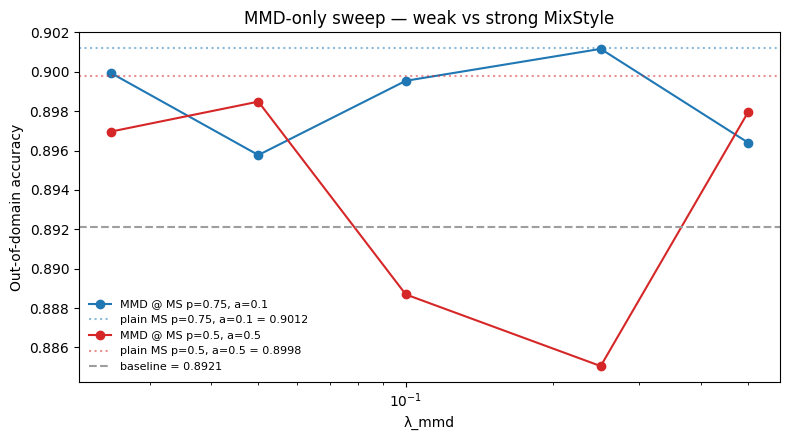

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
any_data = False
for (p, a), color in zip([STRONG_MS, WEAK_MS], ["#1f77b4", "#d62728"]):
    sub = df[(df["family"]=="MMD") & (df["p"]==p) & (df["a"]==a)].sort_values("mmd_lambda")
    if not sub.empty:
        ax.plot(sub["mmd_lambda"], sub["out_acc"], marker="o", color=color,
                label=f"MMD @ MS p={p}, a={a}")
        any_data = True
    ax.axhline(plain_ms_out[f"p={p}, a={a}"], color=color, linestyle=":", alpha=0.5,
               label=f"plain MS p={p}, a={a} = {plain_ms_out[f'p={p}, a={a}']:.4f}")
ax.axhline(baseline_out, color="#9e9e9e", linestyle="--", label=f"baseline = {baseline_out:.4f}")
if any_data:
    ax.set_xscale("log")
else:
    ax.text(0.5, 0.5, "no MMD-only runs yet", ha="center", va="center",
            transform=ax.transAxes, fontsize=11, color="#666")
ax.set_xlabel("λ_mmd")
ax.set_ylabel("Out-of-domain accuracy")
ax.set_title("MMD-only sweep — weak vs strong MixStyle")
ax.legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout()
plt.savefig(HT_FIGURES / "fig3_mmd_sweep.png", bbox_inches="tight")
plt.show()


## Plot 4 — KL+MMD heatmaps (one per MS config)

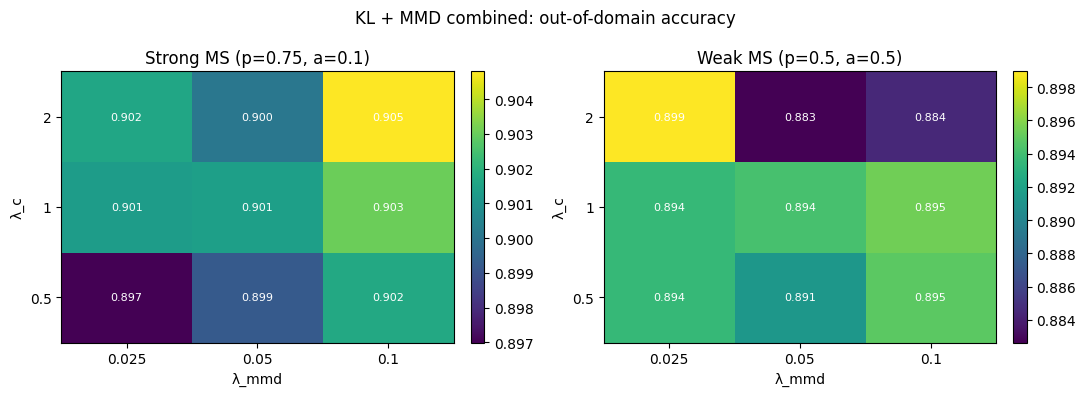

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (p, a), title in zip(axes, [STRONG_MS, WEAK_MS],
                              ["Strong MS (p=0.75, a=0.1)", "Weak MS (p=0.5, a=0.5)"]):
    sub = df[(df["family"]=="KL+MMD") & (df["p"]==p) & (df["a"]==a)]
    if sub.empty:
        ax.text(0.5, 0.5, "no KL+MMD runs yet", ha="center", va="center",
                transform=ax.transAxes, fontsize=11, color="#666")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title)
        continue
    pivot = sub.pivot_table(index="kl_lambda", columns="mmd_lambda", values="out_acc")
    im = ax.imshow(pivot.values, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{c:g}" for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{i:g}" for i in pivot.index])
    ax.set_xlabel("λ_mmd")
    ax.set_ylabel("λ_c")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if pd.isna(v):
                continue
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("KL + MMD combined: out-of-domain accuracy")
plt.tight_layout()
plt.savefig(HT_FIGURES / "fig4_klmmd_heatmaps.png", bbox_inches="tight")
plt.show()


## Plot 5 — 2×4 best-cell summary (headline figure)

Each cell shows the best out-of-domain accuracy from its sweep, plus
the winning hyperparameter. The layout makes the row-wise contrast
between weak vs strong MS — the hypothesis test — easy to read.

,ms_config,family,best_out_acc,hp
0,"p=0.75, a=0.1",KL,0.903579,λ=1
1,"p=0.75, a=0.1",Multiscale,0.899147,w=1
2,"p=0.75, a=0.1",MMD,0.901164,λ=0.25
3,"p=0.75, a=0.1",KL+MMD,0.904803,"λ_c=2, λ_m=0.1"
4,"p=0.5, a=0.5",KL,0.901859,λ=5
5,"p=0.5, a=0.5",Multiscale,0.900834,w=1
6,"p=0.5, a=0.5",MMD,0.898485,λ=0.05
7,"p=0.5, a=0.5",KL+MMD,0.898948,"λ_c=2, λ_m=0.025"


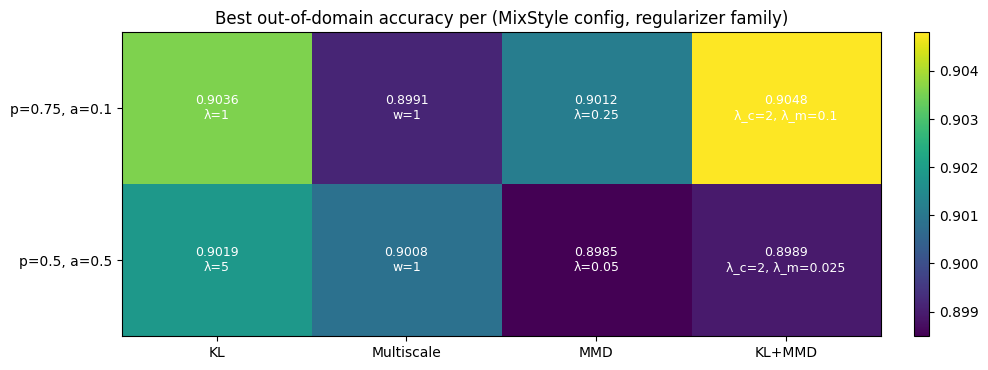

In [7]:
def _hp_label(row):
    if row["family"] == "KL":         return f"λ={row['kl_lambda']:g}"
    if row["family"] == "Multiscale": return f"w={row['ms_w']:g}"
    if row["family"] == "MMD":        return f"λ={row['mmd_lambda']:g}"
    if row["family"] == "KL+MMD":     return f"λ_c={row['kl_lambda']:g}, λ_m={row['mmd_lambda']:g}"
    return ""

best_rows = []
for (p, a) in (STRONG_MS, WEAK_MS):
    for fam in ["KL", "Multiscale", "MMD", "KL+MMD"]:
        sub = df[(df["family"]==fam) & (df["p"]==p) & (df["a"]==a)]
        if sub.empty:
            continue
        b = sub.loc[sub["out_acc"].idxmax()]
        best_rows.append({
            "ms_config": f"p={p}, a={a}",
            "family": fam,
            "best_out_acc": b["out_acc"],
            "hp": _hp_label(b),
        })
best_df = pd.DataFrame(best_rows)
display(best_df)

# Headline figure: 2x4 colored grid
families = ["KL", "Multiscale", "MMD", "KL+MMD"]
ms_labels = [f"p={p}, a={a}" for (p,a) in (STRONG_MS, WEAK_MS)]

if best_df.empty:
    grid    = pd.DataFrame(np.nan, index=ms_labels, columns=families)
    hp_grid = pd.DataFrame("",     index=ms_labels, columns=families)
else:
    grid = best_df.pivot_table(index="ms_config", columns="family", values="best_out_acc")
    grid = grid.reindex(index=ms_labels, columns=families)
    hp_grid = best_df.pivot_table(index="ms_config", columns="family", values="hp", aggfunc="first")
    hp_grid = hp_grid.reindex(index=ms_labels, columns=families)

fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(grid.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(families))); ax.set_xticklabels(families)
ax.set_yticks(range(len(ms_labels))); ax.set_yticklabels(ms_labels)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        if pd.isna(v):
            ax.text(j, i, "—", ha="center", va="center", color="#888", fontsize=11)
            continue
        h = hp_grid.values[i, j]
        ax.text(j, i, f"{v:.4f}\n{h}", ha="center", va="center", color="white", fontsize=9)
ax.set_title("Best out-of-domain accuracy per (MixStyle config, regularizer family)")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
plt.tight_layout()
plt.savefig(HT_FIGURES / "fig5_best_cell_grid.png", bbox_inches="tight")
plt.show()


## Plot 6 — Verdict bar chart

Eight bars (4 families × 2 MS configs), grouped by family with
strong-MS and weak-MS side-by-side. Reference lines for the two plain
MixStyle baselines.

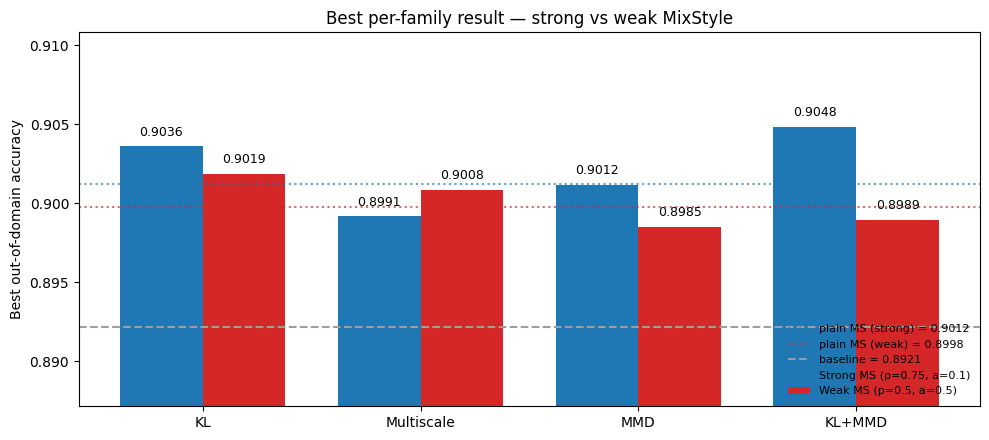

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(families))
w = 0.38

strong_vals = [grid.loc[f"p={STRONG_MS[0]}, a={STRONG_MS[1]}", f] for f in families]
weak_vals   = [grid.loc[f"p={WEAK_MS[0]}, a={WEAK_MS[1]}",   f] for f in families]

b1 = ax.bar(x - w/2, strong_vals, w, label=f"Strong MS (p={STRONG_MS[0]}, a={STRONG_MS[1]})", color="#1f77b4")
b2 = ax.bar(x + w/2, weak_vals,   w, label=f"Weak MS (p={WEAK_MS[0]}, a={WEAK_MS[1]})",   color="#d62728")

# Annotate only bars with real values; mark missing cells with a small "—".
for bars, vals in [(b1, strong_vals), (b2, weak_vals)]:
    for bar, v in zip(bars, vals):
        cx = bar.get_x() + bar.get_width()/2
        if pd.isna(v):
            ax.text(cx, 0, "—", ha="center", va="bottom", fontsize=10, color="#888",
                    transform=ax.get_xaxis_transform())
        else:
            ax.text(cx, v + 0.0005, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

ax.axhline(plain_ms_out[f"p={STRONG_MS[0]}, a={STRONG_MS[1]}"], color="#1f77b4", linestyle=":", alpha=0.7,
           label=f"plain MS (strong) = {plain_ms_out[f'p={STRONG_MS[0]}, a={STRONG_MS[1]}']:.4f}")
ax.axhline(plain_ms_out[f"p={WEAK_MS[0]}, a={WEAK_MS[1]}"], color="#d62728", linestyle=":", alpha=0.7,
           label=f"plain MS (weak) = {plain_ms_out[f'p={WEAK_MS[0]}, a={WEAK_MS[1]}']:.4f}")
ax.axhline(baseline_out, color="#9e9e9e", linestyle="--",
           label=f"baseline = {baseline_out:.4f}")

ax.set_xticks(x); ax.set_xticklabels(families)
ax.set_ylabel("Best out-of-domain accuracy")
ax.set_title("Best per-family result — strong vs weak MixStyle")
ax.legend(fontsize=8, frameon=False, loc="lower right")

# NaN-safe y-range — fall back to plain-MS / baseline references when a row is empty.
all_vals = [v for v in strong_vals + weak_vals if not pd.isna(v)]
all_vals += list(plain_ms_out.values()) + [baseline_out]
y_lo = min(all_vals) - 0.005
y_hi = max(all_vals) + 0.006
ax.set_ylim(y_lo, y_hi)
plt.tight_layout()
plt.savefig(HT_FIGURES / "fig6_verdict_bars.png", bbox_inches="tight")
plt.show()


## Final verdict

For each regularizer family, print the gain over plain MixStyle in
its respective regime, then print the headline diagonal contrast.
Hypothesis is **supported** when both diagonal deltas are positive.

In [9]:
def _best(fam, ms):
    return grid.loc[f"p={ms[0]}, a={ms[1]}", fam]

def _gain(fam, ms):
    b = _best(fam, ms)
    if pd.isna(b):
        return float("nan")
    return b - plain_ms_out[f"p={ms[0]}, a={ms[1]}"]

def _fmt(v):
    return "       —" if pd.isna(v) else f"{v:>+8.4f}"

print("=" * 68)
print(f"{'family':<12s} {'gain over plain MS':>22s}     {'gain over plain MS':>22s}")
print(f"{'':<12s} {'(strong MS)':>22s}     {'(weak MS)':>22s}")
print("-" * 68)
for fam in families:
    print(f"{fam:<12s} {_fmt(_gain(fam, STRONG_MS)):>22s}     {_fmt(_gain(fam, WEAK_MS)):>22s}")
print("=" * 68)

d_weak   = _best("Multiscale", WEAK_MS)   - _best("KL", WEAK_MS)
d_strong = _best("KL", STRONG_MS)         - _best("Multiscale", STRONG_MS)
print()
print(f"Δ weak  MS  =  best(Multiscale) − best(KL)         = {_fmt(d_weak)}")
print(f"Δ strong MS =  best(KL)         − best(Multiscale) = {_fmt(d_strong)}")
print()

if pd.isna(d_weak) or pd.isna(d_strong):
    missing = []
    if pd.isna(_best("Multiscale", WEAK_MS)):   missing.append("Multiscale @ weak MS")
    if pd.isna(_best("KL",         WEAK_MS)):   missing.append("KL @ weak MS")
    if pd.isna(_best("KL",         STRONG_MS)): missing.append("KL @ strong MS")
    if pd.isna(_best("Multiscale", STRONG_MS)): missing.append("Multiscale @ strong MS")
    print("Verdict: ⚠ INCOMPLETE — missing cell(s): " + ", ".join(missing))
elif d_weak > 0 and d_strong > 0:
    print("Verdict: ✓ hypothesis SUPPORTED — stronger reg wins at weak MS, weaker reg wins at strong MS.")
elif d_weak <= 0 and d_strong <= 0:
    print("Verdict: ✗ hypothesis CONTRADICTED — the opposite pairing wins on both rows.")
else:
    print("Verdict: ⚠ hypothesis PARTIALLY supported — only one of the two paired comparisons goes the predicted way.")


family           gain over plain MS         gain over plain MS
                        (strong MS)                  (weak MS)
--------------------------------------------------------------------
KL                          +0.0024                    +0.0021
Multiscale                  -0.0021                    +0.0011
MMD                         -0.0000                    -0.0013
KL+MMD                      +0.0036                    -0.0008

Δ weak  MS  =  best(Multiscale) − best(KL)         =  -0.0010
Δ strong MS =  best(KL)         − best(Multiscale) =  +0.0044

Verdict: ⚠ hypothesis PARTIALLY supported — only one of the two paired comparisons goes the predicted way.
